# CorrDiff Prediction Pipeline - CENTRALIZED CONFIGURATION

Simple notebook with centralized parameters for regression and diffusion.

## 1. Configuration

In [1]:
from prediction import DataManager, RegressionPipeline, DiffusionPipeline, Visualizer, MetricsCalculator

In [2]:
# Basic configuration
USE_DUMMY_DATA = False
SAMPLE_INDEX = 100

# Data paths
DATA_PATH = "/mnt/storage/younes.abid/physicsnemo/data/custom_data_2/"
OUTPUT_DIR = "/app/"

data_paths = {
    "data_dir": DATA_PATH + "ERA5_WRF_combined_concatenated_432/",
    "stat_dir": DATA_PATH + "stats_432/"
}

In [3]:
regression_config = {
    "model_config": {
        "N_grid_channels": 4,
        "gridtype": "sinusoidal",
        "embedding_type": "zero",
        "model_channels": 128,
        "channel_mult": [1, 2, 2, 2, 2],
        "attn_resolutions": [28],
        "model_type": "SongUNetPosEmbd",
    },
    "checkpoint_config": {
        "checkpoint_dir": OUTPUT_DIR + "checkpoints_regression",
        "checkpoint_index": 535008
    }
}

In [4]:
# DIFFUSION CONFIGURATION (FIXED - EXACT match with train.py create_loss_function)
diffusion_config = {
    "model_config": {
        # Model architecture from diffusion_normal.yaml (COMPLETE)
        "gridtype": "sinusoidal",
        "N_grid_channels": 4,
        "embedding_type": "zero",
        "model_channels": 128,
        "channel_mult": [1, 2, 2, 2, 2],
        "attn_resolutions": [28],
        "model_type": "SongUNetPosEmbd",
        
        # EDM parameters (use ResidualLoss defaults - NOT explicitly passed in train.py!)
        # These will use the class defaults: P_mean=0.0, P_std=1.2, sigma_data=0.5
        
        # Model execution config
        "use_fp16": False,
        "checkpoint_level": 0,
        "hr_mean_conditioning": True,  # CRITICAL: This is the ONLY parameter passed to ResidualLoss in train.py
    },
    "execution_config": {
        # Execution parameters from train.py validation
        "use_apex_gn": False,
        "enable_amp": False,
        "amp_dtype": "float32",
        "profile_mode": False,
        "batch_size_per_gpu": 1,
        "use_patch_grad_acc": None,
        "patching": None,
        "patch_nums_iter": [1],
    },
    "checkpoint_config": {
        "checkpoint_dir": OUTPUT_DIR + "checkpoints_diffusion/",
        "checkpoint_index": 265008,
        "regression_checkpoint_path": OUTPUT_DIR + "checkpoints_regression/UNet.0.535008.mdlus",
    }
}

## 2. Data Management

In [5]:
data_manager = DataManager(data_paths, use_dummy_data=USE_DUMMY_DATA)
stats = data_manager.load_statistics()
input_data, output_data = data_manager.load_sample_data(sample_idx=SAMPLE_INDEX)
data_manager.get_variable_statistics(show_all=False)

✓ Statistics loaded
✓ Sample 100 corresponds to: 2024-05-11 04:00:00
  - Date: 2024-05-11
  - Time: 04:00:00
  - Day of week: Saturday
✓ Data loaded successfully
  - Input variables: ['t_850', 't_500', 'z_850', 'z_500', 'u_850', 'u_500', 'v_850', 'v_500', 'u10', 'v10', 't2m', 'd2m', 'skt', 'sst', 'sp', 'tcwv', 'tp']
  - Output variables: ['T2', 'U10', 'V10', 'rain_rate', 'SST', 'TSK', 'Q2', 'PSFC']
  - Input shape: FrozenMappingWarningOnValuesAccess({'y_lr': 432, 'x_lr': 432})
  - Output shape: FrozenMappingWarningOnValuesAccess({'y_hr': 432, 'x_hr': 432})

✓ Input variable statistics:
  - t_850: min=294.010, max=298.331, mean=296.839
  - t_500: min=265.850, max=270.004, mean=267.926
  - z_850: min=14762.330, max=15115.711, mean=14871.624
  - z_500: min=57659.094, max=58051.484, mean=57919.656
  - u_850: min=-12.246, max=11.332, mean=0.211
  ... and 12 more variables

✓ Output variable statistics:
  - T2: min=289.884, max=310.716, mean=300.759
  - U10: min=-16.294, max=9.283, mean=1.72

## 3. Regression Pipeline

In [6]:
regression_pipeline = RegressionPipeline(
    regression_config["model_config"], 
    regression_config["checkpoint_config"]
)

regression_loaded = regression_pipeline.load_model()
if regression_loaded:
    print("✓ Regression model loaded successfully")
else:
    print("✗ Failed to load regression model")

=== Creating Regression Model ===
Regression model created with:
  - Input channels: 20 (16 variables + 4 grid)
  - Output channels: 2 (U10, V10)
  - Resolution: 432x432
  - Model channels: 128
  - Channel multipliers: [1, 2, 2, 2, 2]
=== Loading Regression Model ===


`DistributedManager` not initialized already. Initializing now, but this might lead to unexpected errors
/app/physicsnemo/distributed/manager.py:415: UserWarning: Could not initialize using ENV, SLURM or OPENMPI methods. Assuming this is a single process job
  warn(


✓ Regression model loaded successfully from epoch 535008
✓ Model set to evaluation mode
✓ Model moved to device: cuda
✓ Regression model loaded successfully


In [7]:
if regression_loaded:
    input_tensor = data_manager.prepare_input_tensor(apply_manual_normalization=True)
    regression_output, u10_reg, v10_reg = regression_pipeline.predict(input_tensor, data_manager)
    u10_true, v10_true = data_manager.get_ground_truth()
    print("✓ Regression prediction completed")

Preparing input variables: 16 variables
Apply manual normalization: True
⚠️  WARNING: Applying manual normalization. This should match training preprocessing exactly!
  - t_850: manually normalized range [-0.102, 0.535]
  - t_500: manually normalized range [0.012, 1.178]
  - z_850: manually normalized range [0.067, 0.991]
  - z_500: manually normalized range [0.857, 2.153]
  - u_850: manually normalized range [-3.292, 2.441]
  - u_500: manually normalized range [-0.752, 0.161]
  - v_850: manually normalized range [-4.411, 1.685]
  - v_500: manually normalized range [-0.983, 0.709]
  - u10: manually normalized range [-1.897, 2.406]
  - v10: manually normalized range [-2.754, 1.581]
  - t2m: manually normalized range [-0.787, 0.896]
  - d2m: manually normalized range [-1.763, 1.274]
  - skt: manually normalized range [-0.492, 0.869]
  - sp: manually normalized range [-4.564, 0.942]
  - tcwv: manually normalized range [-1.738, -0.184]
  - tp: manually normalized range [-0.061, -0.035]

✓ 

/app/physicsnemo/models/diffusion/layers.py:712: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


✓ Real data inference time: 470.59 ms
✓ Regression output shape: torch.Size([1, 2, 432, 432])
✓ Regression output range (NORMALIZED): [-4.829, 2.594]
✓ Predictions denormalized
  - U10 range (DENORMALIZED): [-13.365, 8.079]
  - V10 range (DENORMALIZED): [-17.487, 6.115]
✓ Regression prediction completed


In [8]:
if regression_loaded and 'u10_reg' in locals():
    metrics_calc = MetricsCalculator()
    regression_metrics = metrics_calc.compute_corrected_regression_metrics(
        u10_reg, v10_reg, u10_true, v10_true, data_manager
    )
    print(f"Regression R²: {regression_metrics['overall_r2']:.4f}")
    print(f"Regression RMSE: {regression_metrics['overall_rmse']:.4f}")

=== Computing CORRECTED Regression Performance Metrics ===
Note: Models work in normalized space, so proper comparison requires normalization
U10 (Wind Component):
  - MAE (denorm): 0.9085
  - RMSE (denorm): 1.2653
  - R² (normalized space): 0.8071
  - R² (denorm space): 0.8071
  - Pred mean: 1.6643, True mean: 1.7200
  - Pred std: 2.6887, True std: 2.8809

V10 (Wind Component):
  - MAE (denorm): 1.0998
  - RMSE (denorm): 1.4356
  - R² (normalized space): 0.6743
  - R² (denorm space): 0.6743
  - Pred mean: -2.3191, True mean: -2.9457
  - Pred std: 2.2181, True std: 2.5157

Overall Performance:
  - Average MAE (denorm): 1.0042
  - Average RMSE (denorm): 1.3505
  - Average R² (normalized space): 0.7407

✓ Key insight: R² in normalized space reflects model's actual learning capability
Regression R²: 0.7407
Regression RMSE: 1.3505


## 4. Diffusion Pipeline

In [9]:
diffusion_pipeline = DiffusionPipeline(diffusion_config)

diffusion_loaded = diffusion_pipeline.load_model()
if diffusion_loaded:
    regression_for_diffusion_loaded = diffusion_pipeline.load_regression_model()
    if regression_for_diffusion_loaded:
        loss_fn_created = diffusion_pipeline.create_loss_function()
        if loss_fn_created:
            print("✓ All diffusion components loaded")

🎯 CENTRALIZED: Initializing DiffusionPipeline with notebook parameters
✓ Deterministic inference configured:
   - Fixed seed: 42
   - cuDNN deterministic: True
   - TF32 disabled: True
📋 CENTRALIZED parameters loaded:
   Device: cuda
   Deterministic mode: enabled
🔧 Creating diffusion model with CENTRALIZED parameters...
📊 Data-derived parameters (computed automatically):
   dataset_channels: 16
   img_in_channels: 18
   img_out_channels: 2
   img_shape: [432, 432]
   hr_mean_conditioning: True
🏗️  CENTRALIZED model parameters:
   img_out_channels: 2
   img_resolution: [432, 432]
   use_fp16: False
   checkpoint_level: 0
   gridtype: sinusoidal
   N_grid_channels: 4
   embedding_type: zero
   model_channels: 128
   channel_mult: [1, 2, 2, 2, 2]
   attn_resolutions: [28]
   model_type: SongUNetPosEmbd
   total_in_channels: 22
✓ Model created and moved to cuda
✓ Diffusion model loaded from epoch 265008
   Checkpoint dir: /app/checkpoints_diffusion/
   Model mode: eval
   Model requires_g

/app/physicsnemo/models/module.py:182: UserWarning: New argument 'use_apex_gn' added for UNet.
  warnings.warn(f"New argument '{key}' added for {cls.__name__}.")


✓ Regression model loaded successfully
   Model mode: eval
   Model requires_grad: False
🔧 Creating loss function with EXACT train.py parameters...
✓ ResidualLoss created with EXACT train.py parameters:
   hr_mean_conditioning: True
   P_mean: 0.0 (class default)
   P_std: 1.2 (class default)
   sigma_data: 0.5 (class default)
✓ All diffusion components loaded


In [10]:
if (diffusion_loaded and regression_for_diffusion_loaded and loss_fn_created and 
    regression_loaded and 'regression_output' in locals()):
    
    input_tensor = data_manager.prepare_input_tensor(apply_manual_normalization=True)
    diffusion_predictions, u10_diff, v10_diff = diffusion_pipeline.predict(
        input_tensor, regression_output, data_manager
    )
    print("✓ Diffusion prediction completed")

Preparing input variables: 16 variables
Apply manual normalization: True
⚠️  WARNING: Applying manual normalization. This should match training preprocessing exactly!
  - t_850: manually normalized range [-0.102, 0.535]
  - t_500: manually normalized range [0.012, 1.178]
  - z_850: manually normalized range [0.067, 0.991]
  - z_500: manually normalized range [0.857, 2.153]
  - u_850: manually normalized range [-3.292, 2.441]
  - u_500: manually normalized range [-0.752, 0.161]
  - v_850: manually normalized range [-4.411, 1.685]
  - v_500: manually normalized range [-0.983, 0.709]
  - u10: manually normalized range [-1.897, 2.406]
  - v10: manually normalized range [-2.754, 1.581]
  - t2m: manually normalized range [-0.787, 0.896]
  - d2m: manually normalized range [-1.763, 1.274]
  - skt: manually normalized range [-0.492, 0.869]
  - sp: manually normalized range [-4.564, 0.942]
  - tcwv: manually normalized range [-1.738, -0.184]
  - tp: manually normalized range [-0.061, -0.035]

✓ 

In [11]:
if 'u10_diff' in locals() and 'v10_diff' in locals():
    diffusion_metrics = metrics_calc.compute_corrected_regression_metrics(
        u10_diff, v10_diff, u10_true, v10_true, data_manager
    )
    print(f"Diffusion R²: {diffusion_metrics['overall_r2']:.4f}")
    print(f"Diffusion RMSE: {diffusion_metrics['overall_rmse']:.4f}")
    
    if 'regression_metrics' in locals():
        r2_improvement = diffusion_metrics['overall_r2'] - regression_metrics['overall_r2']
        print(f"R² Improvement: {r2_improvement:+.4f}")

=== Computing CORRECTED Regression Performance Metrics ===
Note: Models work in normalized space, so proper comparison requires normalization
U10 (Wind Component):
  - MAE (denorm): 1.0435
  - RMSE (denorm): 1.4064
  - R² (normalized space): 0.7617
  - R² (denorm space): 0.7617
  - Pred mean: 1.5614, True mean: 1.7200
  - Pred std: 2.7299, True std: 2.8809

V10 (Wind Component):
  - MAE (denorm): 1.2021
  - RMSE (denorm): 1.5666
  - R² (normalized space): 0.6122
  - R² (denorm space): 0.6122
  - Pred mean: -2.3423, True mean: -2.9457
  - Pred std: 2.2974, True std: 2.5157

Overall Performance:
  - Average MAE (denorm): 1.1228
  - Average RMSE (denorm): 1.4865
  - Average R² (normalized space): 0.6869

✓ Key insight: R² in normalized space reflects model's actual learning capability
Diffusion R²: 0.6869
Diffusion RMSE: 1.4865
R² Improvement: -0.0538


## 5. Visualization

=== Three-Way Comparison Visualization ===

=== U10 Wind Component Comparison ===


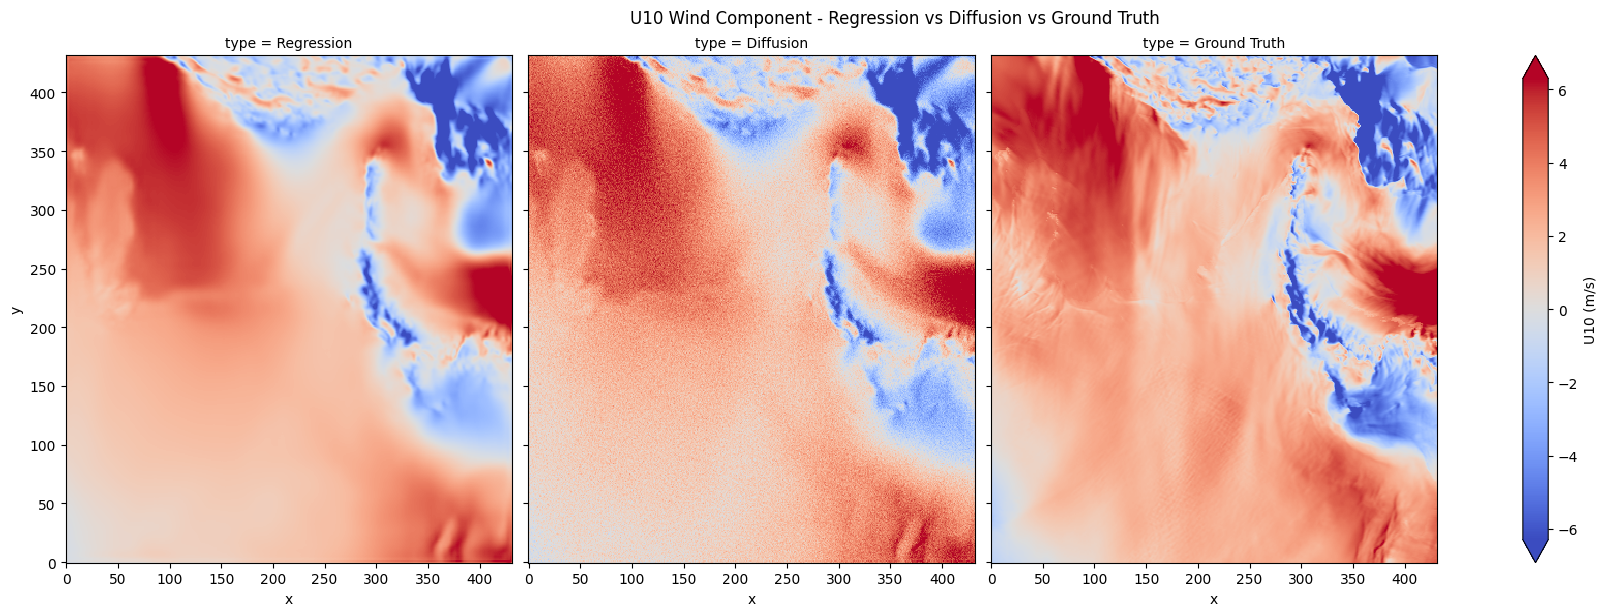


=== V10 Wind Component Comparison ===


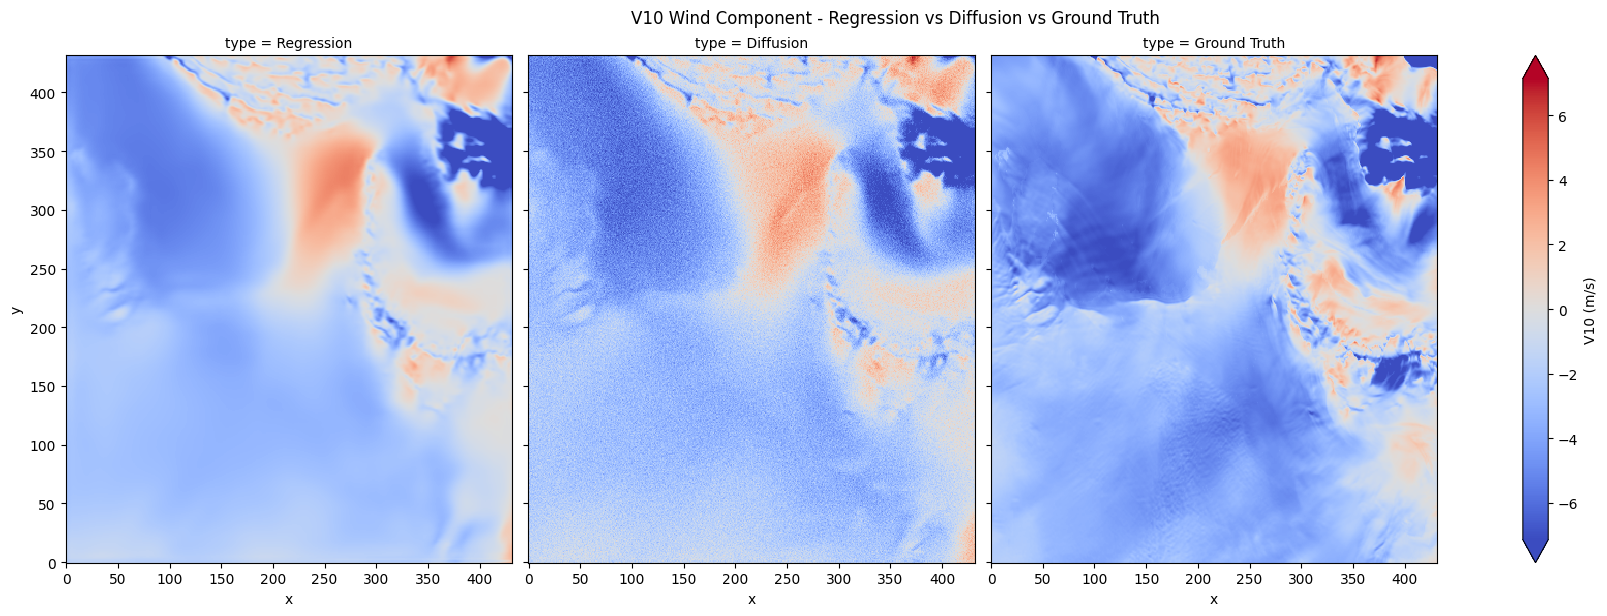


=== Residuals Comparison ===


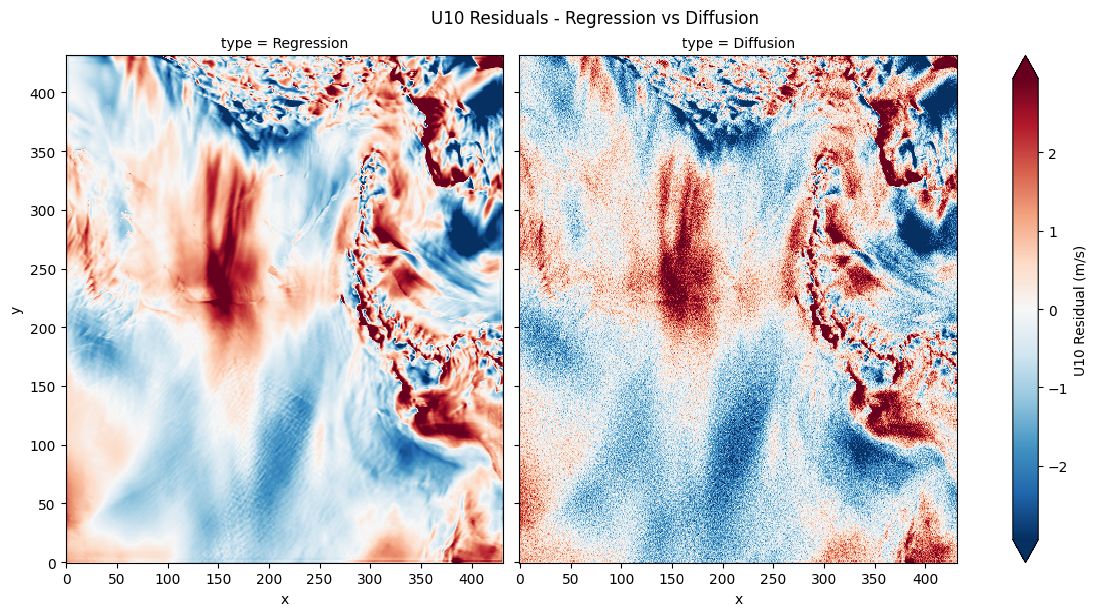

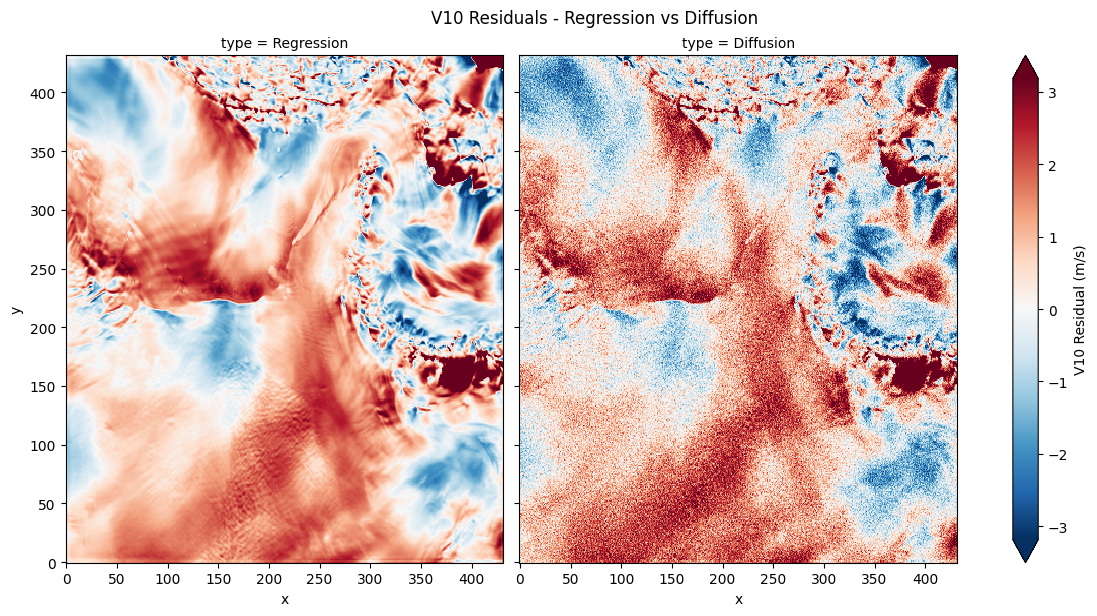

✓ Three-way comparison visualization completed


In [12]:
if ('u10_reg' in locals() and 'u10_diff' in locals()):
    visualizer = Visualizer()
    visualizer.plot_comparison(
        regression_pred=(u10_reg, v10_reg),
        diffusion_pred=(u10_diff, v10_diff),
        ground_truth=(u10_true, v10_true)
    )